# 01 · Exploratory data analysis — FLEX (PSI-69)

**Everything in this notebook is an observed NASA result** (274 ISS droplet tests, March 2009 – December 2011).
No model is trained here. Rates are raw shares of tests; intervals are 95% Wilson intervals, which matter because
many bins hold only a handful of tests.

Questions:
1. What conditions were actually tested — and where are the gaps?
2. How does the outcome depend on oxygen, suppressant (diluent), fuel, droplet size and pressure?
3. Which variables are confounded with each other (by the adaptive test design or by time)?
4. Are the validation groups usable for grouped cross-validation?

Input: `data/processed/combustion_master.csv` (built by `scripts/build_master.py`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import display
from flameguard import eda

eda.use_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

df = eda.load_master()
print(df.shape)

(274, 34)


## 1. Overview

In [2]:
display(pd.crosstab(df["fuel"], df["outcome_raw"], margins=True))
display(pd.crosstab([df["fuel"]], df["diluent"], margins=True))
eda.rate_table(df, ["fuel", "diluent"]).round(2)

outcome_raw,Completion,Disruption,Extinction,All
fuel,,,,
Heptane,19,38,60,117
Methanol,8,23,126,157
All,27,61,186,274


diluent,CO2,He,N2,All
fuel,,,,
Heptane,48,22,47,117
Methanol,75,28,54,157
All,123,50,101,274


,fuel,diluent,n,sustained,rate,ci_low,ci_high
0,Heptane,CO2,48,21,0.44,0.31,0.58
1,Heptane,He,22,8,0.36,0.20,0.57
2,Heptane,N2,47,28,0.60,0.45,0.72
3,Methanol,CO2,75,14,0.19,0.11,0.29
4,Methanol,He,28,2,0.07,0.02,0.23
5,Methanol,N2,54,15,0.28,0.18,0.41


**Read-out.** Heptane sustains combustion far more often than methanol under every diluent
(N₂-only: 60% vs 28%). Raw rates *across* diluents are **not** a fair suppressant comparison yet — section 2 shows the
diluents were tested at different oxygen levels.

In [3]:
eda.missingness_table(df)

,missing,share
flow_cm_s,274,1.000
d_ext_mm,77,0.281
burn_rate_mm2_s,16,0.058
d0_mm,12,0.044
burn_time_s,6,0.022
p_o2_atm,1,0.004
pressure_mmhg,1,0.004
pressure_atm,1,0.004


`flow_cm_s` is missing by design (quiescent chamber). `d_ext_mm`, `burn_rate_mm2_s` and `burn_time_s` are
post-outcome and will never be model inputs. The one that matters is **`d0_mm` (12 tests)**, examined in section 7.

## 2. The test matrix — what was tested

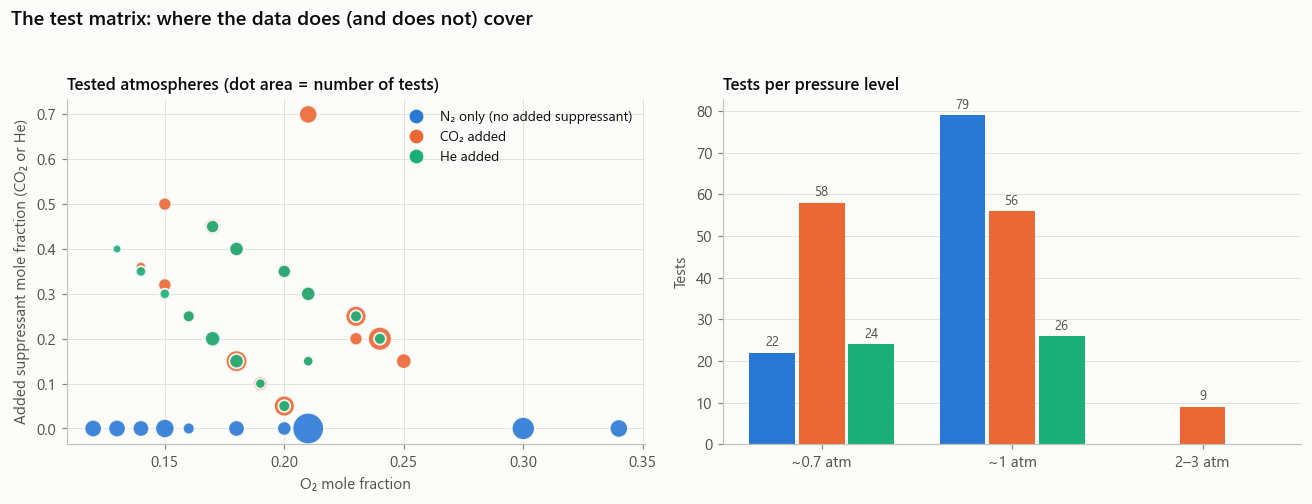

In [4]:
fig = eda.plot_design_space(df)
_ = eda.save(fig, "03_design_space")

In [5]:
# Within each suppressant series, how tied together are O2 and the suppressant fraction?
rows = []
for dil, col in [("CO2", "x_co2"), ("He", "x_he")]:
    for lvl, g in df[df["diluent"] == dil].groupby("pressure_level"):
        if g[col].nunique() > 1:
            rows.append({"diluent": dil, "pressure": lvl, "tests": len(g),
                         "corr(O2, suppressant)": round(g["x_o2"].corr(g[col]), 2)})
pd.DataFrame(rows)

,diluent,pressure,tests,"corr(O2, suppressant)"
0,CO2,0.7atm,58,-0.99
1,CO2,1atm,56,-0.41
2,He,0.7atm,24,-0.99
3,He,1atm,26,-0.93


**Read-out.**
- Suppressant tests (CO₂, He) cover O₂ ≈ 0.13–0.25 only; O₂ 0.30–0.34 exists **only without added suppressant**.
- All 9 tests at 2–3 atm are one CO₂ series (O₂ 0.21, CO₂ 0.70). Nothing else was tested above ~1 atm.
- **Within a series, O₂ and suppressant moved together**: in the He series and the 0.7 atm CO₂ series the
  correlation is about −0.93 to −0.99 — suppressant was added *while* oxygen was removed. The data therefore cannot
  cleanly separate "less oxygen" from "more suppressant" inside those series.

Consequences: a what-if like "add 10% CO₂ at fixed O₂" leaves the tested region and must be flagged as
extrapolation; SHAP credit between `x_o2` and `x_he`/`x_co2` will be partly arbitrary; suppressant comparison should
follow NASA's own design (limiting oxygen per diluent), not "same O₂, different suppressant".

## 3. Outcomes across the condition space

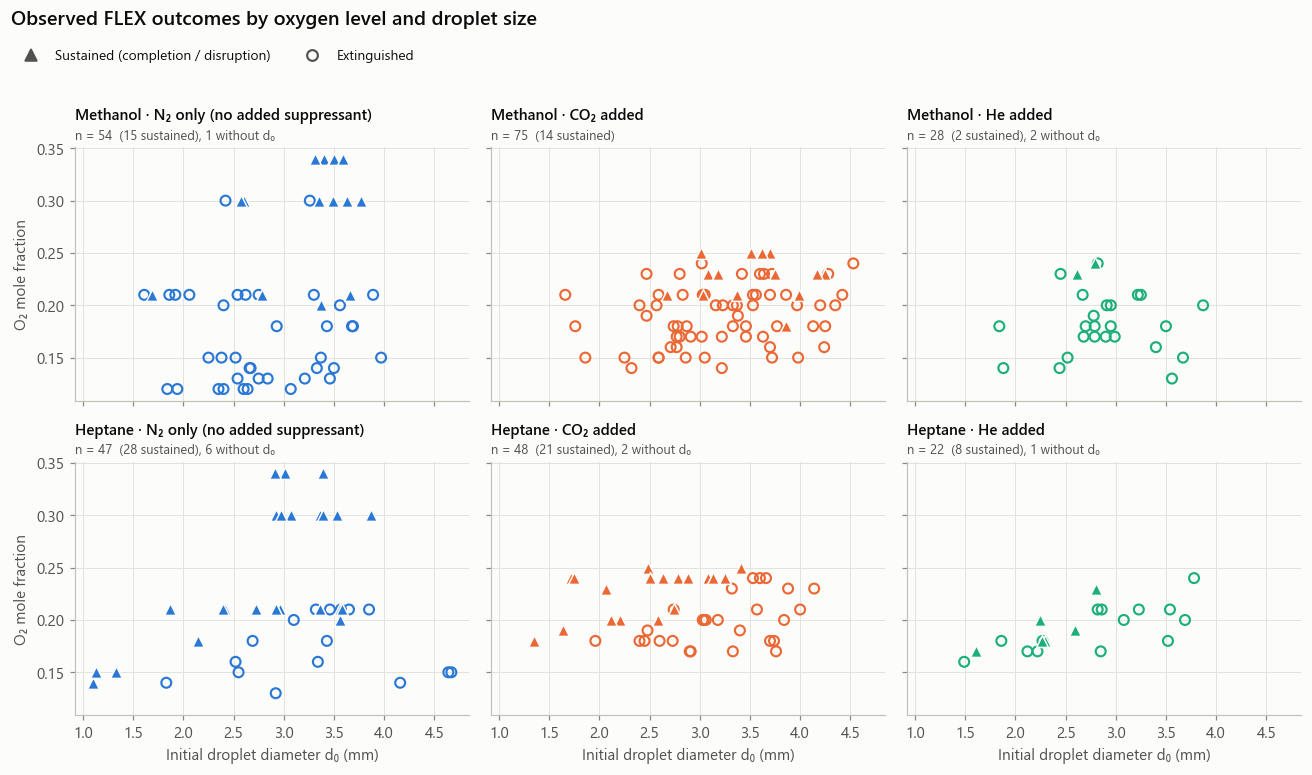

In [6]:
fig = eda.plot_flammability_map(df)
_ = eda.save(fig, "01_flammability_map")

**Read-out.** Oxygen dominates: sustained burning (▲) clusters at high O₂ in every panel and almost vanishes
below ~0.17 for methanol. Heptane sustains at lower O₂ than methanol. There is real overlap — at the same O₂ both
outcomes occur — so O₂ alone does not determine the result.

,fuel,diluent,o2_bin,n,sustained,rate,ci_low,ci_high
0,Heptane,CO2,"(0.16, 0.18]",13,2,0.15,0.04,0.42
1,Heptane,CO2,"(0.18, 0.2]",11,4,0.36,0.15,0.65
2,Heptane,CO2,"(0.2, 0.22]",4,1,0.25,0.05,0.70
3,Heptane,CO2,"(0.22, 0.26]",20,14,0.70,0.48,0.85
4,Heptane,He,"(0.14, 0.16]",1,0,0.00,0.00,0.79
5,Heptane,He,"(0.16, 0.18]",11,5,0.45,0.21,0.72
6,Heptane,He,"(0.18, 0.2]",4,2,0.50,0.15,0.85
7,Heptane,He,"(0.2, 0.22]",4,0,0.00,0.00,0.49
8,Heptane,He,"(0.22, 0.26]",2,1,0.50,0.09,0.91
9,Heptane,N2,"(0.11, 0.14]",6,1,0.17,0.03,0.56


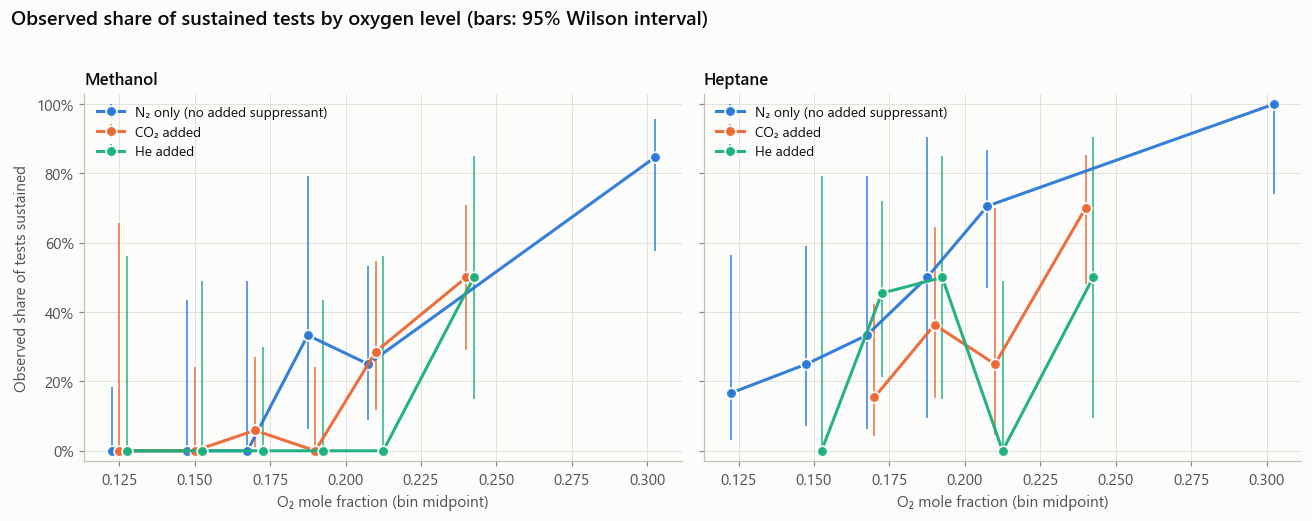

In [7]:
fig, rate_by_o2 = eda.plot_rate_vs_o2(df, bins=[0.11, 0.14, 0.16, 0.18, 0.20, 0.22, 0.26, 0.35])
_ = eda.save(fig, "02_sustained_rate_vs_o2")
rate_by_o2[["fuel", "diluent", "o2_bin", "n", "sustained", "rate", "ci_low", "ci_high"]].round(2)

**Read-out.** The sustained share rises with O₂ overall, but bins with fewer than ~10 tests have intervals
spanning most of 0–100%. The dips in heptane CO₂/He near O₂ 0.21 rest on 4–7 tests and are within noise.
At matched O₂ (0.20–0.22), N₂-only atmospheres look most permissive, but sample sizes are too small to rank CO₂ vs He
from raw rates — that needs the model-based limiting-oxygen comparison planned for Phase 9.

## 4. Single-variable signal

In [8]:
eda.univariate_auc(df, ["x_o2", "p_o2_atm", "x_co2", "x_he", "x_n2", "d0_mm", "pressure_atm"])

,variable,auc,direction,n
0,x_o2,0.821,higher -> more sustained,274
1,p_o2_atm,0.777,higher -> more sustained,273
2,x_co2,0.569,higher -> more extinction,274
3,d0_mm,0.564,higher -> more extinction,262
4,x_he,0.556,higher -> more extinction,274
5,x_n2,0.547,higher -> more sustained,274
6,pressure_atm,0.508,higher -> more sustained,273


**Read-out.** O₂ mole fraction alone separates outcomes well (AUC ≈ 0.82, descriptive, no validation split).
O₂ *partial pressure* is weaker (≈ 0.78), and pressure alone carries almost nothing (≈ 0.51) — over this range the
mole fraction, not the partial pressure, tracks the outcome. Every other variable is weak on its own, which is
expected when effects are conditional (e.g. droplet size matters near the limit).

## 5. Droplet size

In [9]:
sized = df.assign(d0_quartile=eda.size_quartiles(df)).dropna(subset=["d0_quartile"])
display(eda.rate_table(sized, ["fuel", "d0_quartile"]).round(2))

# Same comparison inside a narrow oxygen band (0.20-0.25) to take out the O2 difference between quartiles
band = df[df["x_o2"].between(0.20, 0.25)].dropna(subset=["d0_mm"])
band = band.assign(d0_tercile=band.groupby("fuel", group_keys=False)["d0_mm"].apply(
    lambda s: pd.qcut(s, 3, labels=["small", "medium", "large"])))
display(eda.rate_table(band, ["fuel", "d0_tercile"]).round(2))

# Which outcome replaces 'sustained' as heptane droplets get larger?
hep = sized[sized["fuel"] == "Heptane"]
pd.crosstab(hep["d0_quartile"], hep["outcome_raw"])

,fuel,d0_quartile,n,sustained,rate,ci_low,ci_high
0,Heptane,Q1: 1.1–2.4 mm,27,19,0.70,0.52,0.84
1,Heptane,Q2: 2.4–2.9 mm,28,14,0.50,0.33,0.67
2,Heptane,Q3: 2.9–3.4 mm,26,13,0.50,0.32,0.68
3,Heptane,Q4: 3.4–4.7 mm,27,5,0.19,0.08,0.37
4,Methanol,Q1: 1.6–2.6 mm,39,4,0.10,0.04,0.24
5,Methanol,Q2: 2.6–3.0 mm,39,5,0.13,0.06,0.27
6,Methanol,Q3: 3.0–3.6 mm,37,11,0.30,0.17,0.46
7,Methanol,Q4: 3.6–4.5 mm,39,11,0.28,0.17,0.44


,fuel,d0_tercile,n,sustained,rate,ci_low,ci_high
0,Heptane,small,19,17,0.89,0.69,0.97
1,Heptane,medium,18,8,0.44,0.25,0.66
2,Heptane,large,19,4,0.21,0.09,0.43
3,Methanol,small,23,5,0.22,0.10,0.42
4,Methanol,medium,22,7,0.32,0.16,0.53
5,Methanol,large,22,7,0.32,0.16,0.53


outcome_raw,Completion,Disruption,Extinction
d0_quartile,,,
Q1: 1.1–2.4 mm,10,9,8
Q2: 2.4–2.9 mm,5,9,14
Q3: 2.9–3.4 mm,3,10,13
Q4: 3.4–4.7 mm,1,4,22


**Read-out — the droplet-size effect depends on the fuel** (pooling the fuels hides this):
- **Heptane:** larger droplets are much less often sustained (≈ 70% → 19% from smallest to largest quartile), and the
  pattern holds inside the narrow O₂ 0.20–0.25 band (≈ 89% → 21%). The share of *extinctions* rises with size, so it is
  not just disruption labelling. This is consistent with the radiative extinction of larger droplets documented in
  NASA/TP-2015-216046 (correlation in this data, not a demonstrated mechanism).
- **Methanol:** a weak opposite trend (≈ 10% → 28%), mostly gone inside the O₂ band (≈ 22% → 32%, overlapping
  intervals); larger methanol droplets were also tested at somewhat higher O₂.
- The FLEX procedure increased droplet size step by step until extinction, so size is partly set by the test design.

Consequence: the model must allow a **fuel × droplet-size interaction** — tree models do this natively; a logistic
regression needs an explicit `fuel × d0` term or it will average two opposite effects.

## 6. Campaign timeline — confounding with time

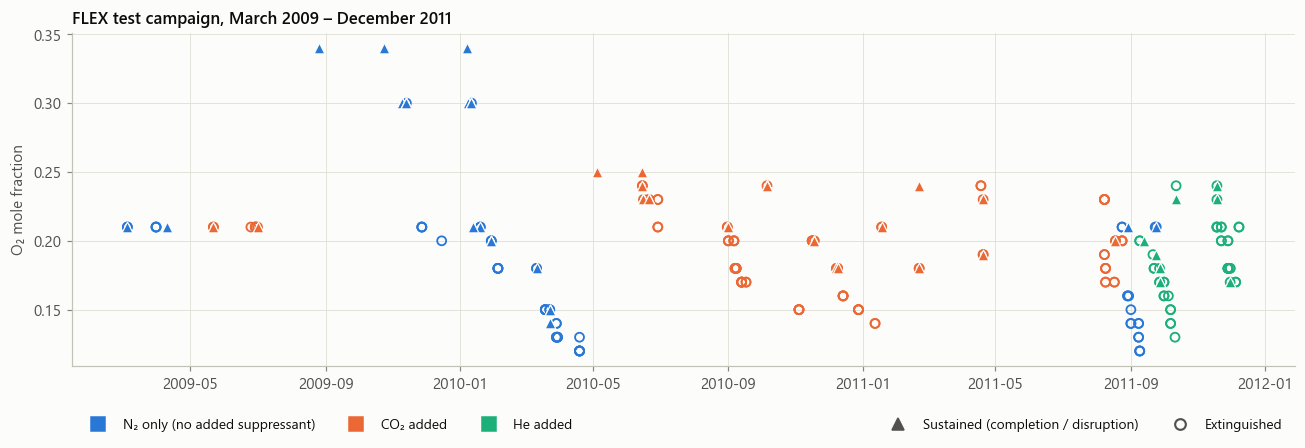

In [10]:
fig = eda.plot_campaign_timeline(df)
_ = eda.save(fig, "04_campaign_timeline")

**Read-out.** The campaign ran in blocks: N₂ series (2009 – early 2010), CO₂ series (mid 2010 – mid 2011),
then N₂ again and **all He tests in late 2011**. Diluent is therefore confounded with time (hardware state, crew
procedures, fuel batches). Within each block the adaptive "step O₂ down until it stops burning" pattern is visible.
A held-out-diluent test (e.g. train without He, test on He) is a test of generalisation across *both* suppressant and
campaign period.

## 7. Missing droplet diameter

In [11]:
df.loc[df["d0_mm"].isna(), ["test_id", "flex_identifier", "fuel", "diluent", "x_o2", "pressure_level", "outcome_raw"]]

,test_id,flex_identifier,fuel,diluent,x_o2,pressure_level,outcome_raw
8,9,30CAL07,Heptane,N2,0.21,1atm,Disruption
23,24,196F003,Heptane,N2,0.34,0.7atm,Disruption
52,53,209F002,Heptane,N2,0.21,1atm,Disruption
79,80,207F001,Heptane,N2,0.13,1atm,Extinction
80,81,207F002,Heptane,N2,0.13,1atm,Extinction
82,83,304F002,Methanol,N2,0.12,1atm,Extinction
95,96,C08H301,Heptane,CO2,0.24,0.7atm,Disruption
137,138,C21H304,Heptane,CO2,0.24,1atm,Disruption
209,210,N02H201,Heptane,N2,0.16,1atm,Extinction
222,223,H01M104,Methanol,He,0.20,1atm,Extinction


**Read-out.** 12 tests lack d₀; 9 are heptane and 6 are disruptions (sustained). Dropping them removes 6 of 88
sustained tests (7%), mostly heptane at O₂ ≥ 0.21 — a region already well covered. Recommendation: drop them for the
primary model and run a sensitivity check with an imputed d₀ + missing-indicator.

## 8. Validation groups

,grouping,groups,median_size,largest,largest_share,single_outcome_groups
0,group_id_fill,79,2,13,0.047,72%
1,group_id_atmosphere,45,5,29,0.106,49%


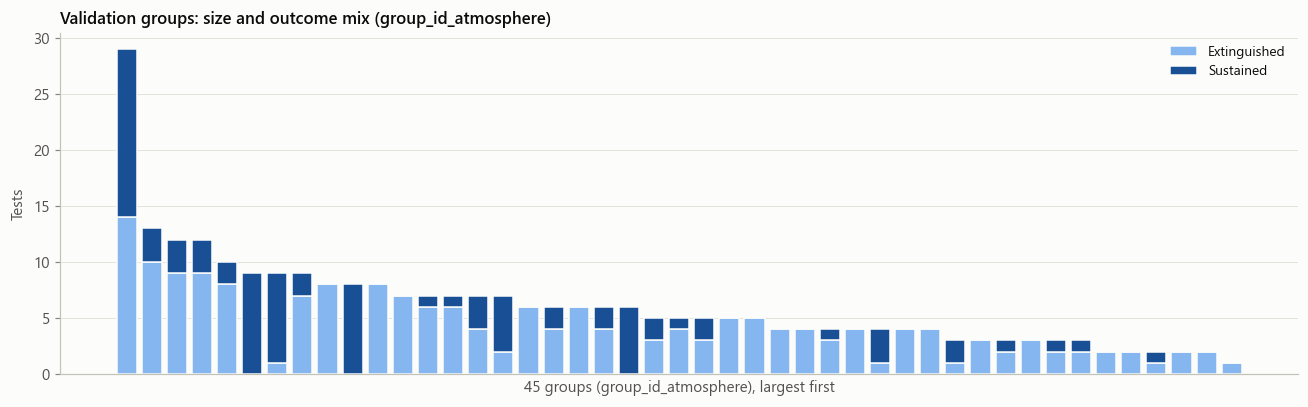

In [12]:
display(eda.group_purity_table(df, ["group_id_fill", "group_id_atmosphere"]))
fig = eda.plot_group_sizes(df, "group_id_atmosphere")
_ = eda.save(fig, "05_group_sizes_atmosphere")

**Read-out.** `group_id_atmosphere` gives 45 groups; the largest (29 tests, 11% of data) is cabin-air-like
O₂ 0.21 at 1 atm. About half the groups contain only one outcome, so per-fold class balance will vary —
`StratifiedGroupKFold` with 5 folds is feasible and should be repeated over several seeds. The group structure is
the reason a random row split would overstate performance: tests sharing an atmosphere are near-duplicates in
every input except d₀.

## Summary — decisions carried into Phases 5–7

| # | Finding (observed) | Decision |
|---|---|---|
| 1 | O₂ mole fraction is the dominant single signal (AUC ≈ 0.82) | Expect it to dominate the model; check the model is not *only* O₂ |
| 2 | Heptane sustains more than methanol everywhere | Keep `fuel` as a feature; report results per fuel |
| 3 | Suppressant tests only cover O₂ 0.13–0.25; >1 atm only one CO₂ series | Bound what-if inputs to tested ranges; treat 2–3 atm as out of scope for predictions |
| 4 | O₂ and suppressant are near-collinear within series (r ≈ −0.93…−0.99) | Flag off-diagonal what-ifs as extrapolation; interpret SHAP for O₂ vs suppressant jointly; compare suppressants via limiting-O₂ per diluent |
| 5 | Diluent confounded with campaign period | Add a leave-one-diluent-out stress test; avoid causal language about suppressants |
| 6 | Droplet size: strong effect for heptane (larger → extinction), weak for methanol; partly set by test procedure | Keep `d0_mm` with a fuel × d₀ interaction; drop 12 tests without d₀ in primary model, sensitivity check with imputation |
| 7 | 45 atmosphere groups, ~half single-outcome | Repeated `StratifiedGroupKFold` on `group_id_atmosphere` as primary validation |
